## Introduction

This notebook serves to provide valuable data insights into the evaluations I choose for the NLP model. In here, I'll be using matplotlib.pyplot, seaborn, and possibly some audio visualizations to represent patterns in similar music genres as well as songs in general.

This notebook is mostly meant for visualization but can be custom-made in-order to visualize your own data you choose to modify the model with

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
    print("Cuda device is available")
elif not torch.backends.mps.is_available():
    device= "cpu"
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    device = "mps"
    print("Mac device available")

print(device)

Mac device available
mps


Index(['num', 'track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')


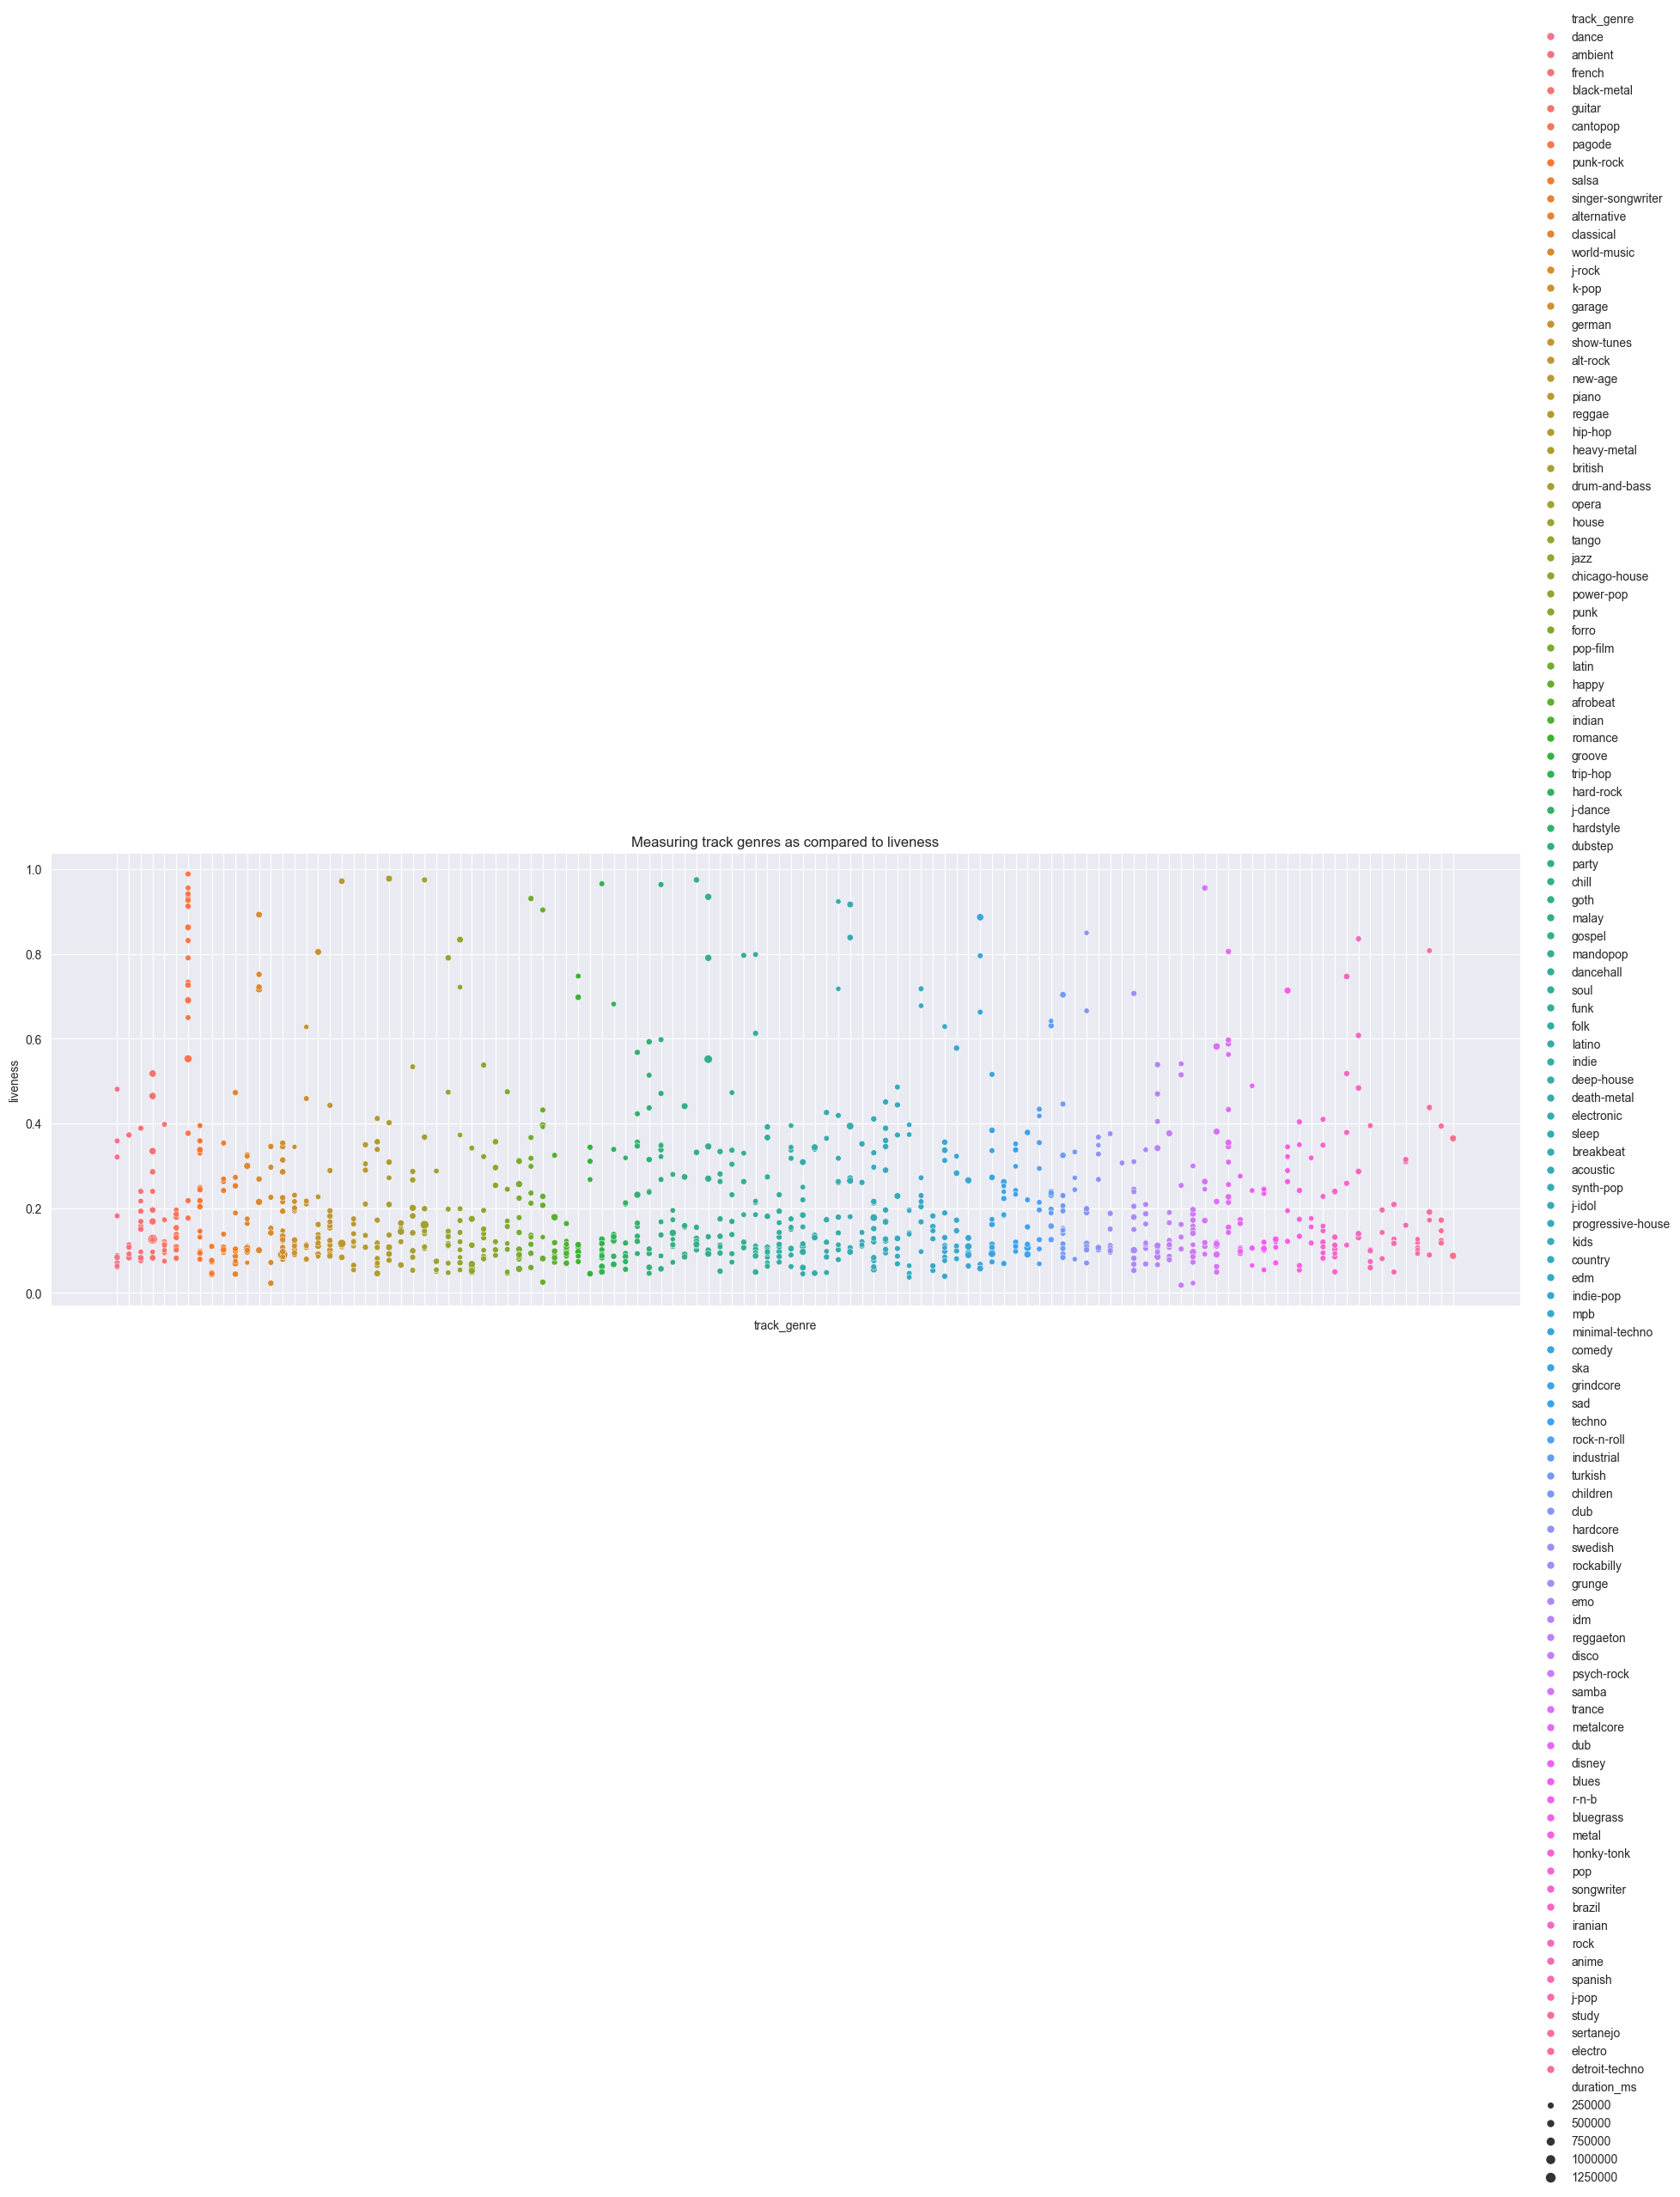

In [3]:
# We start by importing our libraries and plotting our model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from load_data import df
import random

# We are going to plot several interactions between our data to see what patterns we can draw
random.seed(50)
optimized_random_df = df.sample(n=1000, random_state=50)
beg = sns.relplot(data=optimized_random_df, x="track_genre", y="liveness",hue='track_genre', size="duration_ms",kind="scatter", legend="auto", height =6, aspect=3)
beg.set(xticklabels=[])
beg.set(title="Measuring track genres as compared to liveness")
plt.show()


In [4]:
print(len(df["track_genre"].unique()))

114


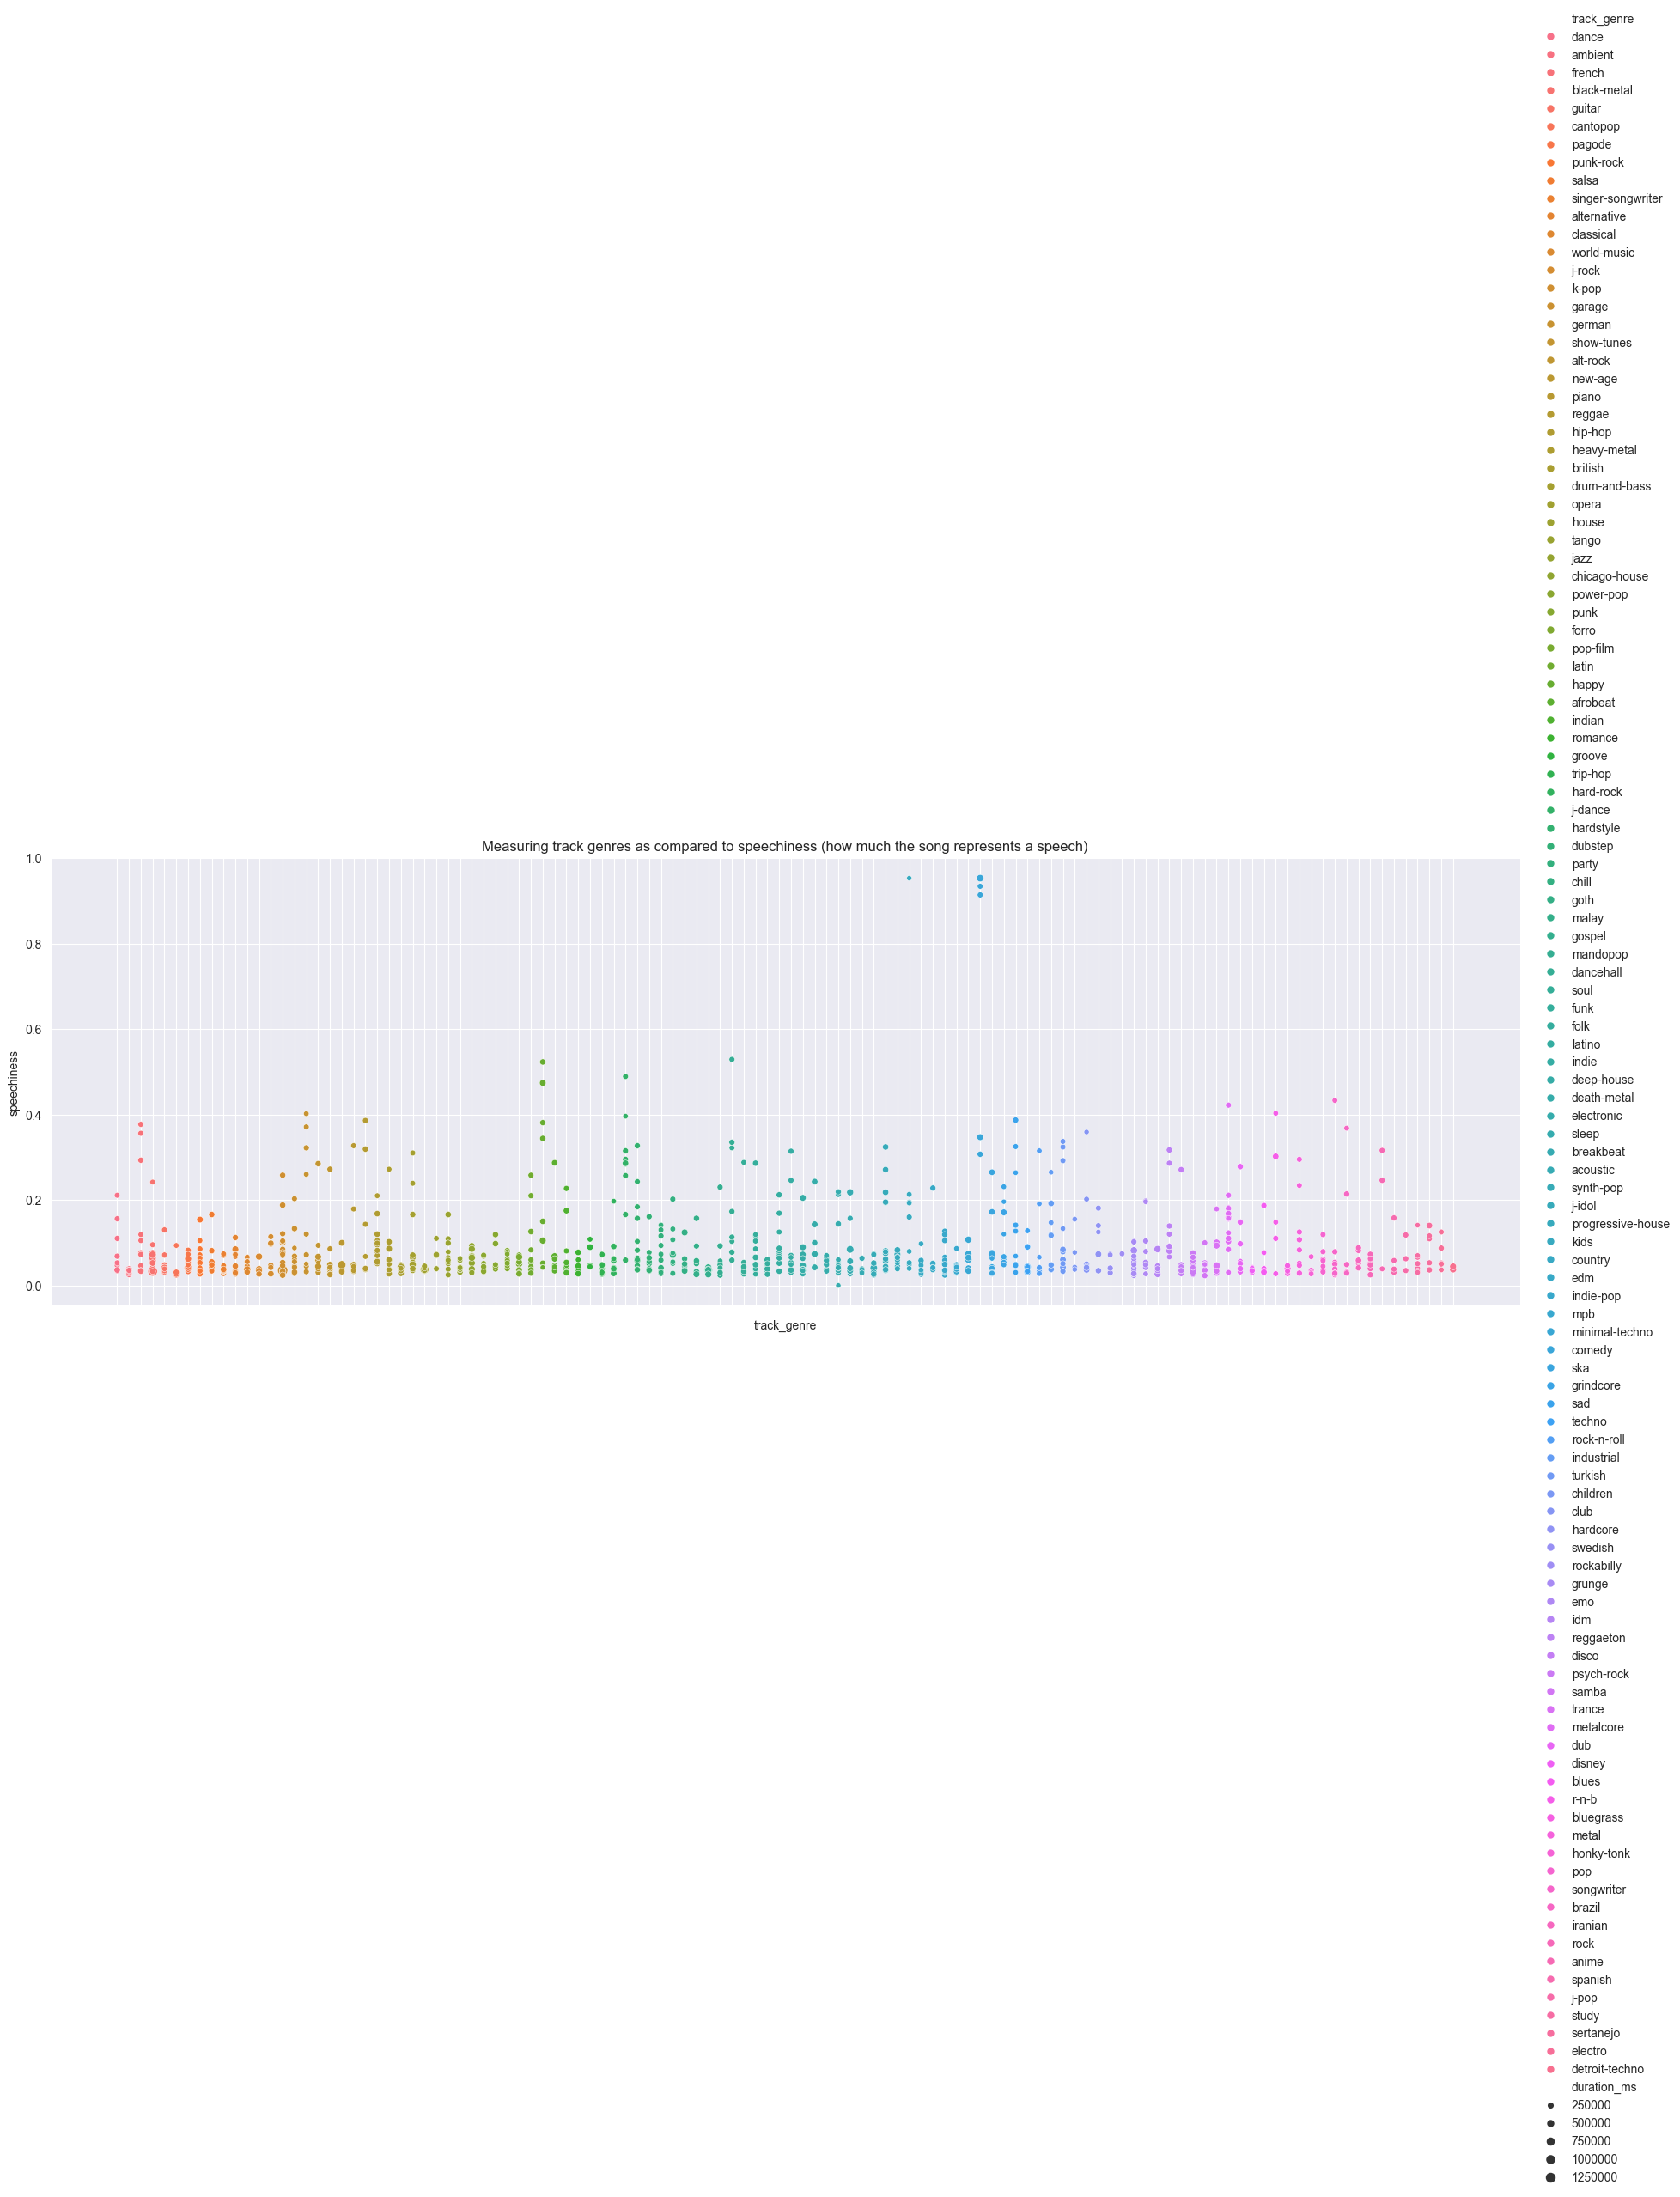

In [5]:
val = sns.relplot(data=optimized_random_df, x="track_genre", y="speechiness",hue='track_genre', size="duration_ms",kind="scatter", legend="auto", height =6, aspect=3)
val.set(xticklabels=[])
val.set(title="Measuring track genres as compared to speechiness (how much the song represents a speech)")
plt.show()


We can see from the data above that there may be a strong correlation between the genre of a spotify song as well as its liveliness and speechiness. This may prove helpful to predicting songs.

## Investigating further relationships

Now that we have an idea about what variables may help us find similar songs for our engine, we now want to see the relationships between them. Is there a correlation between speechiness and liveness, and can we reveal anything about how genres can vary using this.

### Mean values grid of speechiness against liveness

The following grid will show us how speechiness correlates with liveness based on the variation from the mean.

[[Text(0, 0, ''),
  Text(1, 0, ''),
  Text(2, 0, ''),
  Text(3, 0, ''),
  Text(4, 0, ''),
  Text(5, 0, ''),
  Text(6, 0, ''),
  Text(7, 0, ''),
  Text(8, 0, ''),
  Text(9, 0, ''),
  Text(10, 0, ''),
  Text(11, 0, ''),
  Text(12, 0, ''),
  Text(13, 0, ''),
  Text(14, 0, ''),
  Text(15, 0, ''),
  Text(16, 0, ''),
  Text(17, 0, ''),
  Text(18, 0, ''),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, ''),
  Text(24, 0, ''),
  Text(25, 0, ''),
  Text(26, 0, ''),
  Text(27, 0, ''),
  Text(28, 0, ''),
  Text(29, 0, ''),
  Text(30, 0, ''),
  Text(31, 0, ''),
  Text(32, 0, ''),
  Text(33, 0, ''),
  Text(34, 0, ''),
  Text(35, 0, ''),
  Text(36, 0, ''),
  Text(37, 0, ''),
  Text(38, 0, ''),
  Text(39, 0, ''),
  Text(40, 0, ''),
  Text(41, 0, ''),
  Text(42, 0, ''),
  Text(43, 0, ''),
  Text(44, 0, ''),
  Text(45, 0, ''),
  Text(46, 0, ''),
  Text(47, 0, ''),
  Text(48, 0, ''),
  Text(49, 0, ''),
  Text(50, 0, ''),
  Text(51, 0, ''),
  Text(52, 0, ''),
  T

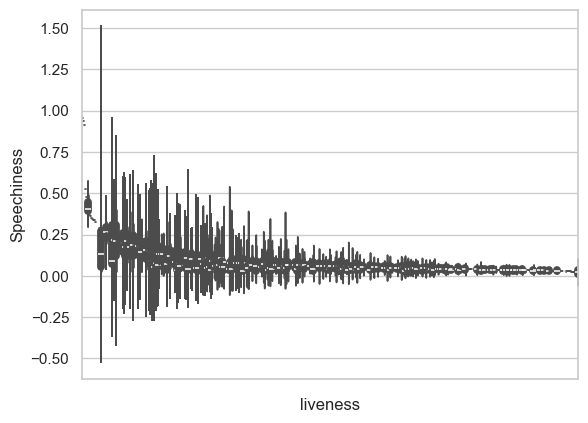

In [101]:
mean_values = optimized_random_df.groupby('liveness')['speechiness'].mean().sort_values(ascending=False)
sns.set_theme(style="whitegrid")
ax = sns.violinplot(x='liveness', y='speechiness', data=optimized_random_df, order=mean_values.index)
ax.set(xticklabels= [], ylabel="Speechiness")


<Axes: xlabel='track_genre', ylabel='liveness'>

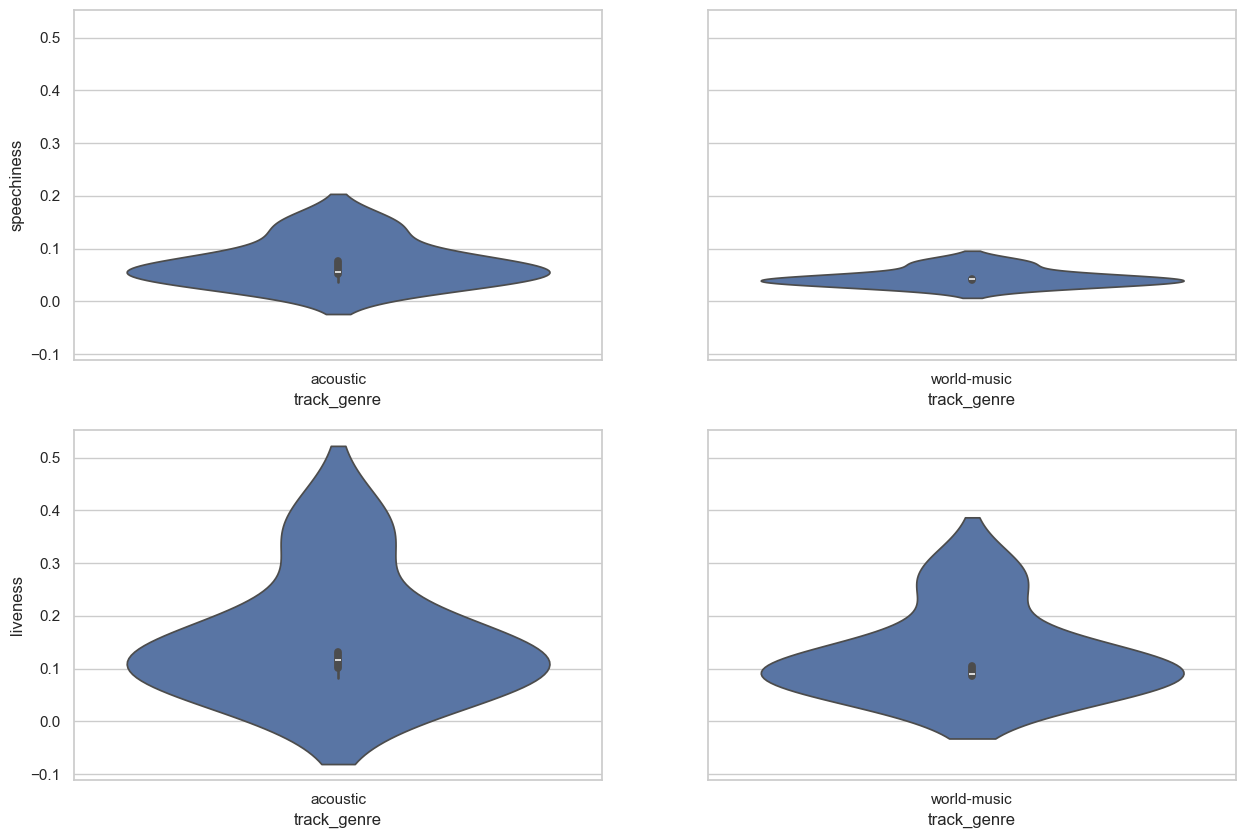

In [62]:
df_head = df.head(5)
df_tail = df.tail(5)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
sns.violinplot(ax=axes[0][0], x='track_genre', y='speechiness', data=df_head)
sns.violinplot(ax=axes[0][1], x='track_genre', y='speechiness', data=df_tail)
sns.violinplot(ax=axes[1][0], x='track_genre', y='liveness', data=df_head)
sns.violinplot(ax=axes[1][1], x='track_genre', y='liveness', data=df_tail)



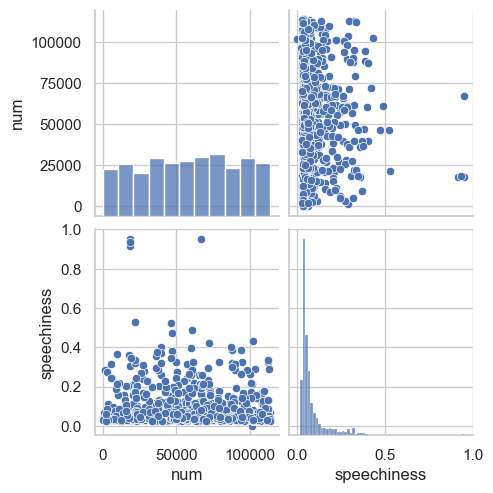

In [90]:
sns.pairplot(data=optimized_random_df, vars = ["num", "speechiness"])

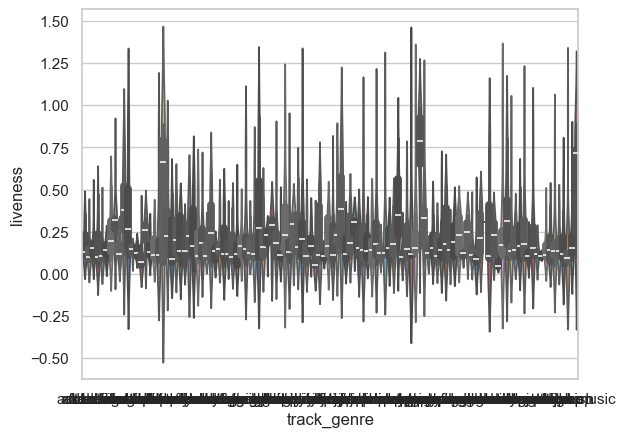

In [103]:
grouped_dfs = {}
for category, group_df in optimized_random_df.groupby('track_genre'):
    grouped_dfs[category] = group_df

for category in grouped_dfs:
    sns.pairplot(data=grouped_dfs[category][:5], vars=["track_genre", "speechiness"])